<a href="https://colab.research.google.com/github/medipallysreeya-gif/Machine-learning-skill/blob/main/Week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/Titanic-Dataset.csv')

Connecting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected successfully!

Searching for Titanic-Dataset.csv...

File found!
Location: /content/drive/MyDrive/Colab/Titanic-Dataset.csv

Dataset loaded successfully!

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Hen

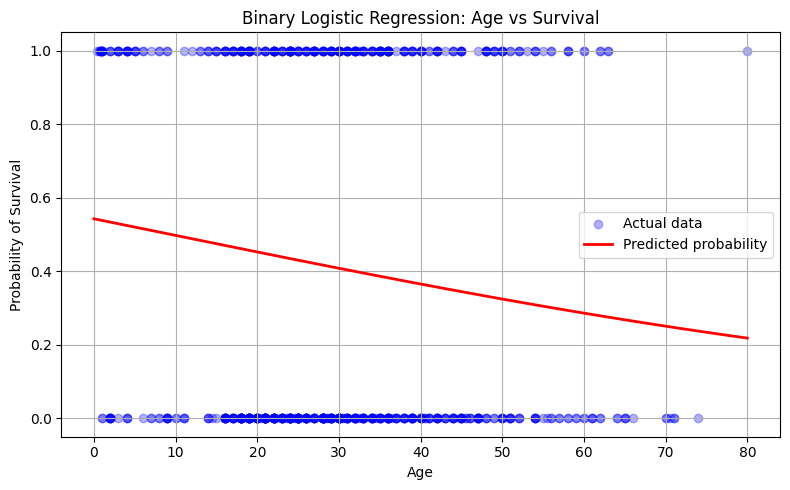


PROGRAM COMPLETED SUCCESSFULLY!


In [10]:
# =========================================================
# BINARY LOGISTIC REGRESSION - AGE vs SURVIVED (Titanic)
# Google Colab + Google Drive
# =========================================================

# ---------------------------------------------------------
# STEP 1: Import libraries
# ---------------------------------------------------------
import os
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ---------------------------------------------------------
# STEP 2: Mount Google Drive
# ---------------------------------------------------------
print("Connecting Google Drive...")
drive.mount('/content/drive')
print("Google Drive connected successfully!")

# ---------------------------------------------------------
# STEP 3: Find Titanic-Dataset.csv automatically
# ---------------------------------------------------------
print("\nSearching for Titanic-Dataset.csv...")

file_path = None
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.lower() == 'titanic-dataset.csv':
            file_path = os.path.join(root, file)
            break
    if file_path is not None:
        break

# ---------------------------------------------------------
# STEP 4: Check whether file was found
# ---------------------------------------------------------
if file_path is None:
    print("\nERROR: Titanic-Dataset.csv was not found!")
else:
    print("\nFile found!")
    print("Location:", file_path)

    # -----------------------------------------------------
    # STEP 5: Load the dataset
    # -----------------------------------------------------
    df = pd.read_csv(file_path)
    print("\nDataset loaded successfully!")

    # -----------------------------------------------------
    # STEP 6: Display dataset information
    # -----------------------------------------------------
    print("\nFirst 5 rows:")
    print(df.head())
    print("\nDataset shape:", df.shape)
    print("\nColumn names:", df.columns.tolist())

    # -----------------------------------------------------
    # STEP 7: Clean column names
    # -----------------------------------------------------
    df.columns = df.columns.str.strip()

    # -----------------------------------------------------
    # STEP 8: Check required columns
    # -----------------------------------------------------
    if "Age" not in df.columns or "Survived" not in df.columns:
        print("\nERROR! Titanic dataset must contain 'Age' and 'Survived'")
    else:
        # =================================================
        # PART 1: BINARY LOGISTIC REGRESSION
        # =================================================
        print("\nFeature: Age")
        print("Target: Survived (0 = Did not survive, 1 = Survived)")

        # -------------------------------------------------
        # STEP 9: Select feature and target
        # -------------------------------------------------
        df = df.dropna(subset=["Age"])  # drop missing ages
        X = df[["Age"]]
        y = df["Survived"]

        # -------------------------------------------------
        # STEP 10: Split dataset
        # -------------------------------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
        print("\nTraining samples:", len(X_train))
        print("Testing samples:", len(X_test))

        # -------------------------------------------------
        # STEP 11: Create Logistic Regression model
        # -------------------------------------------------
        binary_model = LogisticRegression()
        binary_model.fit(X_train, y_train)
        print("\nModel trained successfully!")

        # -------------------------------------------------
        # STEP 12: Predict test data
        # -------------------------------------------------
        y_pred = binary_model.predict(X_test)

        # -------------------------------------------------
        # STEP 13: Accuracy
        # -------------------------------------------------
        accuracy = accuracy_score(y_test, y_pred)
        print("\nAccuracy:", accuracy)

        # -------------------------------------------------
        # STEP 14: Classification Report
        # -------------------------------------------------
        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

        # -------------------------------------------------
        # STEP 15: Confusion Matrix
        # -------------------------------------------------
        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))

        # -------------------------------------------------
        # STEP 16: Predict for new ages
        # -------------------------------------------------
        new_age = pd.DataFrame({"Age": [5, 25, 60]})
        predictions = binary_model.predict(new_age)
        probabilities = binary_model.predict_proba(new_age)[:, 1]

        print("\nPredictions for new passengers:")
        for age_val, pred, prob in zip(new_age["Age"], predictions, probabilities):
            survival_status = "Survived" if pred == 1 else "Did not survive"
            print(f"Age {age_val}: {survival_status} (Probability of survival = {prob:.2f})")

        # -------------------------------------------------
        # STEP 17: Logistic Regression S-Curve
        # -------------------------------------------------
        plt.figure(figsize=(8, 5))
        plt.scatter(df["Age"], df["Survived"], color="blue", alpha=0.3, label="Actual data")

        age_range = pd.DataFrame({"Age": range(int(df["Age"].min()), int(df["Age"].max()) + 1)})
        predicted_probability = binary_model.predict_proba(age_range)[:, 1]

        plt.plot(age_range["Age"], predicted_probability, color="red", linewidth=2, label="Predicted probability")
        plt.xlabel("Age")
        plt.ylabel("Probability of Survival")
        plt.title("Binary Logistic Regression: Age vs Survival")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        plot_path = "/content/drive/MyDrive/titanic_logistic_plot.png"
        plt.savefig(plot_path)
        print("\nGraph saved to:", plot_path)
        plt.show()

        print("\nPROGRAM COMPLETED SUCCESSFULLY!")
